In [11]:
# hyperparameter_tuning_starter.py

import numpy as np
import matplotlib.pyplot as plt

In [12]:
# -------------------------
# Data generation
# -------------------------
def generate_data(n=200):
    # generate 200 random 2D points

    rng: np.random.Generator = np.random.default_rng()
    # generate X ~ N(0, I)
    X: np.ndarray = rng.normal(loc=0.0, scale=1.0, size=(n, 2))

    # assign labels using circle rule
    y: np.ndarray = np.zeros(n)
    for i in range(n):
        x1 = X[i, 0]
        x2 = X[i, 1]
        if x1**2 + x2**2 <= 1:
            y[i] = -1
        else:
            y[i] = 1

    return X, y

In [13]:
# -------------------------
# Feature mapping
# -------------------------
def feature_map(X):
    # return [x1, x2, x1^2, x2^2]
    X_mapped = np.zeros((X.shape[0], 4))
    X_mapped[:, 0] = X[:, 0]  # x1
    X_mapped[:, 1] = X[:, 1]  # x2
    X_mapped[:, 2] = X[:, 0] ** 2  # x1^2
    X_mapped[:, 3] = X[:, 1] ** 2  # x2^2

    return X_mapped

In [14]:
# -------------------------
# Split data
# -------------------------
def split_data(X, y):
    n = len(X)
    # randomly shuffle dataset
    rng = np.random.default_rng()
    indices = np.arange(n)
    rng.shuffle(indices)
    X = X[indices]
    y = y[indices]

    # split into train/val/test (60/20/20)
    train_size = int(0.6 * n)
    val_size = int(0.2 * n)
    test_size = int(0.2 * n)

    X_train, y_train = X[:train_size], y[:train_size]
    X_val, y_val = (
        X[train_size : train_size + val_size],
        y[train_size : train_size + val_size],
    )
    # test set is the remaining data
    X_test, y_test = X[train_size + val_size :], y[train_size + val_size :]

    return X_train, y_train, X_val, y_val, X_test, y_test

In [15]:
# -------------------------
# Loss
# -------------------------
def compute_loss(X, y, w, b):
    # Note: X must be mapped features
    loss = 0
    for i, point in enumerate(X):
        z = np.dot(w.transpose(), point) + b
        loss += np.log(1 + np.exp(-y[i] * z))

    # average all over n
    return loss / len(X)

In [16]:
# -------------------------
# Gradients
# -------------------------
def compute_gradients(X, y, w, b):
    # Note: X must be mapped features
    n = len(X)
    dw = np.zeros(w.shape)
    db = 0
    # compute gradients dw and db
    for i, point in enumerate(X):
        u = -y[i] * (np.dot(w.transpose(), point) + b)
        log_derivative = np.exp(u) / (1 + np.exp(u))
        dw += log_derivative * (-y[i] * point)
        db += log_derivative * (-y[i])

    # average all over n
    dw /= n
    db /= n
    return dw, db

In [17]:
# -------------------------
# Training
# -------------------------
def train(X, y, lr, epochs=200):
    # initialize parameters
    w = np.zeros(X.shape[1])
    b = 0

    for _ in range(epochs):
        # compute gradients
        dw, db = compute_gradients(X, y, w, b)

        # update parameters
        w = w - lr * dw
        b = b - lr * db

    return w, b

In [18]:
# -------------------------
# Prediction
# -------------------------
def predict(X, w, b):
    # return -1 or +1
    y_hat = np.zeros(X.shape[0])  # 200 points
    for i, point in enumerate(X):
        z = np.dot(w.transpose(), point) + b
        if z >= 0:
            y_hat[i] = 1
        else:
            y_hat[i] = -1
    return y_hat

In [19]:
# -------------------------
# Error
# -------------------------
def compute_error(y_true, y_pred):
    return np.mean(y_true != y_pred)

Best learning rate: 0.5
Test error: 0.025


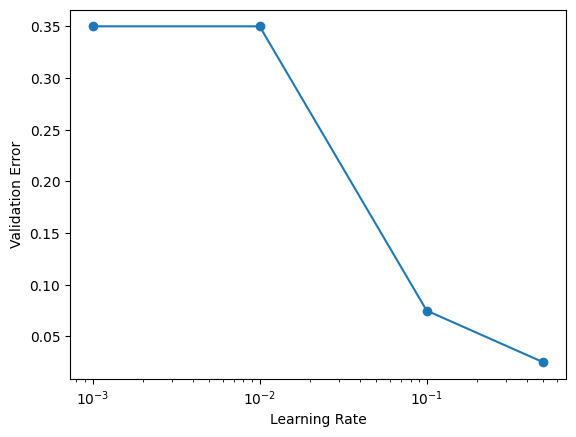

In [20]:
# -------------------------
# Main
# -------------------------
if __name__ == "__main__":
    X, y = generate_data()
    X = feature_map(X)

    data = split_data(X, y)
    X_train, y_train, X_val, y_val, X_test, y_test = data

    learning_rates = [0.001, 0.01, 0.1, 0.5]
    val_errors = []

    for lr in learning_rates:
        w, b = train(X_train, y_train, lr)

        preds_val = predict(X_val, w, b)
        err = compute_error(y_val, preds_val)

        val_errors.append(err)

    # choose best lr
    best_lr = learning_rates[np.argmin(val_errors)]
    print(f"Best learning rate: {best_lr}")

    # retrain on training set
    w, b = train(X_train, y_train, best_lr)

    # evaluate on test set
    preds_test = predict(X_test, w, b)
    test_error = compute_error(y_test, preds_test)
    print(f"Test error: {test_error}")

    # plot validation error vs lr
    plt.plot(learning_rates, val_errors, marker="o")
    plt.xscale("log")  # log scale, e.g., 10^-3, 10^-2, 10^-1 for better visualization
    plt.xlabel("Learning Rate")
    plt.ylabel("Validation Error")
    plt.show()